In [1]:
!pip install -q segmentation-models-pytorch albumentations rasterio tensorboard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 11.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcugraph-cu12 24.12.0 requires pylibraft-cu12==24.12.*, but you have pylibraft-cu12 25.2.0 which is inc

In [2]:
import csv
import os
import pickle
from pathlib import Path

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import segmentation_models_pytorch as smp
import torch
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from skimage.transform import resize
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.profiler import profile, record_function, ProfilerActivity
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.6' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
2025-04-30 18:12:58.664885: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746036778.854112      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746036778.907308      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
SEED = 503
DATA_DIR = '/kaggle/input/cloud-masking-dataset/content/train'
OUTPUT_DIR = '/kaggle/working'
MODEL_PATH = os.path.join(OUTPUT_DIR, 'cloud_mask_deeplab.pkl')
LOGS_PATH = os.path.join(OUTPUT_DIR, 'model_logs.txt')

torch.manual_seed(SEED)
np.random.seed(SEED)

CONFIG = {
    'img_size': 512,
    'batch_size': 8,
    'epochs': 30,
    'learning_rate': 1e-4,
    'val_split': 0.2,
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'bands': ['red', 'green', 'blue', 'infrared'],
}

print(f"Using device: {CONFIG['device']}")

DATASET_PATH = Path(DATA_DIR)
IMAGES_DIR = DATASET_PATH / 'data'
MASKS_DIR = DATASET_PATH / 'masks'

dataset_images_paths = sorted(IMAGES_DIR.rglob("*"))
dataset_masks_paths = sorted(MASKS_DIR.rglob("*"))

print(f"Total images found: {len(dataset_images_paths)}")
print(f"Total masks found: {len(dataset_masks_paths)}")

Using device: cuda
Total images found: 10573
Total masks found: 10573


In [4]:
class CloudDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]
        
        with rasterio.open(img_path) as img_file:
            img = np.stack([img_file.read(i+1) for i in range(4)], axis=2)
            
        with rasterio.open(mask_path) as mask_file:
            mask = mask_file.read(1)
            mask = (mask > 0).astype(np.float32)
        
        img = img.astype(np.float32)
        for i in range(img.shape[2]):
            if np.max(img[:,:,i]) > 0:
                img[:,:,i] = img[:,:,i] / np.max(img[:,:,i])
        
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented['image'], augmented['mask']
        
        img = np.transpose(img, (2, 0, 1))
        mask = np.expand_dims(mask, 0)
        
        return torch.from_numpy(img), torch.from_numpy(mask)

In [5]:
train_transform = A.Compose([
    A.Resize(CONFIG['img_size'], CONFIG['img_size']),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.15),
    A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.15),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.2),
], additional_targets={'mask': 'mask'})

val_transform = A.Compose([
    A.Resize(CONFIG['img_size'], CONFIG['img_size']),
])

In [ ]:
def load_model(path):
    """
    Loads a saved PyTorch model from the specified file path using pickle.

    Args:
        path (str): Path to the pickled model file.

    Returns:
        torch.nn.Module: Loaded PyTorch model moved to the configured device and set to evaluation mode.
    """
    device = CONFIG['device']
    with open(path, 'rb') as f:
        model = pickle.load(f)
    model.to(device)
    model.eval()
    return model

In [ ]:
def compute_all_dice(model, image_paths, mask_paths, config, 
                     csv_out_path="mask_dice_scores.csv", sample_vis_count=12):
    """
    Computes Dice coefficients for all image and mask pairs using the provided model,
    writes results to a CSV file, and retains a specified number of samples for visualization.

    Args:
        model (torch.nn.Module): Trained model for inference.
        image_paths (List[Path]): List of paths to image files.
        mask_paths (List[Path]): List of paths to mask files.
        config (dict): Configuration dictionary with inference parameters.
        csv_out_path (str, optional): Output path for the CSV file with Dice scores. Defaults to "mask_dice_scores.csv".
        sample_vis_count (int, optional): Number of samples to retain for visualization. Defaults to 12.

    Returns:
        List[dict]: List of dictionaries with visualization samples, each containing image, mask, prediction, paths, and dice value.
    """
    device = config['device']
    size = config['img_size']

    vis_sample_buf = []
    dices = []
    paths_info = []

    with open(csv_out_path, "w", newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(["img_path", "mask_path", "dice"])

        pbar = tqdm(total=len(image_paths), desc="Compute Dice/write to CSV")
        for img_path, mask_path in zip(image_paths, mask_paths):
            with rasterio.open(img_path) as img_file:
                img = np.stack([img_file.read(i+1) for i in range(4)], axis=2).astype(np.float32)
                for k in range(img.shape[2]):
                    if img[:,:,k].max() > 0:
                        img[:,:,k] /= img[:,:,k].max()
                img = val_transform(image=img)['image']
            with rasterio.open(mask_path) as mask_file:
                mask = mask_file.read(1)
                mask = (mask > 0).astype(np.float32)
                mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)

            img_tensor = torch.from_numpy(np.transpose(img, (2, 0, 1))).unsqueeze(0).to(device)
            mask_tensor = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0).to(device)
            with torch.no_grad():
                output = model(img_tensor)
                pred = (torch.sigmoid(output) > 0.5).float()
            intersection = torch.sum(mask_tensor * pred)
            dice = (2. * intersection + 1e-6) / (torch.sum(mask_tensor) + torch.sum(pred) + 1e-6)
            dice_val = dice.item()
            writer.writerow([img_path, mask_path, dice_val])

            if len(vis_sample_buf) < sample_vis_count:
                vis_sample_buf.append({
                    "img_path": img_path,
                    "mask_path": mask_path,
                    "dice": dice_val,
                    "img": img[:,:, :3],
                    "mask": mask,
                    "pred": pred.cpu().numpy().squeeze()
                })
            pbar.update(1)
        pbar.close()
    print(f"Done. All Dice scores written to {csv_out_path}. Retained {len(vis_sample_buf)} samples for visualization.")
    return vis_sample_buf

In [ ]:
def show_dice_inspection(dices, thresholds=[0.8, 0.5, 0.2]):
    """
    Displays summary statistics and a histogram of Dice coefficients. Optionally, displays the number of samples above/below given thresholds.

    Args:
        dices (array-like): Array or list of Dice coefficient values.
        thresholds (list, optional): List of float thresholds to inspect the proportion of samples above and below these cutoffs.

    Returns:
        None
    """
    dices = np.array(dices)
    N = len(dices)
    print("--- Dice statistics on dataset masks vs model prediction ---")
    print(f"Min: {dices.min():.4f} | Median: {np.median(dices):.4f} | Mean: {dices.mean():.4f} | Max: {dices.max():.4f}")

    plt.figure(figsize=(10,4))
    plt.hist(dices, bins=50, color='skyblue', edgecolor='black')
    for threshold in thresholds:
        plt.axvline(threshold, color='red', linestyle='--', alpha=0.7, label=f'Thresh {threshold}')
    plt.xlabel("Dice Score")
    plt.ylabel("Count")
    plt.title("Dice Score Distribution (GT Mask vs Model Prediction)")
    plt.legend()
    plt.show()

    for threshold in thresholds:
        kept = np.sum(dices >= threshold)
        removed = np.sum(dices < threshold)
        print(f"If threshold={threshold:.2f}: Kept {kept} ({kept/N:.1%}), Removed {removed} ({removed/N:.1%})")

In [9]:
# NOTE: Uncomment the following if you want to calculate and visualize the model dice scores distribution across the dataset

# deep_lab_model_path = "/kaggle/input/cloud-mask-deep-lab/pytorch/default/1/cloud_mask_deeplab.pkl"
# csv_path = "/kaggle/working/mask_dice_scores_deep_lab.csv"

# deep_lab_model = load_model(deep_lab_model_path)
# vis_samples = compute_all_dice(deep_lab_model, dataset_images_paths, dataset_masks_paths, CONFIG, csv_path)

# ns = len(vis_samples)
# fig, axes = plt.subplots(ns, 3, figsize=(14, 4*ns))
# for i, d in enumerate(vis_samples):
#     axes[i, 0].imshow(d["img"]); axes[i, 0].axis("off"); axes[i, 0].set_title(f"RGB (Dice={d['dice']:.4f})")
#     axes[i, 1].imshow(d["mask"], cmap='gray'); axes[i, 1].axis("off"); axes[i, 1].set_title("GT Mask")
#     axes[i, 2].imshow(d["pred"], cmap='gray'); axes[i, 2].axis("off"); axes[i, 2].set_title("Model Prediction")
# plt.tight_layout()
# plt.show()

# df = pd.read_csv(csv_path)
# show_dice_inspection(df['dice'].values, thresholds=[0.99, 0.98, 0.80, 0.50, 0.30, 0.20, 0.15, 0.10, 0.025])

In [ ]:
def save_all_clear_images(image_paths, mask_paths, output_dir="clear_samples", seed=SEED):
    """
    Scans the dataset for masks with a cloud cover below a specified threshold and saves the
    corresponding images and masks as composite visuals in the designated output directory.

    Args:
        image_paths (List[str]): List of file paths pointing to the RGB image files.
        mask_paths (List[str]): List of file paths pointing to the mask files.
        output_dir (str, optional): Directory to store the saved composite images of clear masks. Defaults to "clear_samples".
        seed (int, optional): Random seed to ensure reproducibility. Defaults to 42.
        clearness_ratio (float, optional): Maximum allowable cloud coverage ratio for a mask to be considered cloud-free. Defaults to 0.025.
    
    Returns:
        None
    """
    os.makedirs(output_dir, exist_ok=True)
    clear_indices = []
    print("Scanning for cloud-free masks...")
    for idx, mask_path in enumerate(mask_paths):
        with rasterio.open(mask_path) as msrc:
            mask = msrc.read(1)
            if np.sum(mask > 0) == 0:
                clear_indices.append(idx)

    total_clear = len(clear_indices)
    print(f"Total cloud-free masks: {total_clear} ({100*total_clear/len(mask_paths):.2f}%)")
    if total_clear == 0:
        print("No clear/cloud-free masks found.")
        return

    for i, idx in enumerate(clear_indices):
        with rasterio.open(image_paths[idx]) as imgsrc:
            img = np.stack([imgsrc.read(i+1) for i in range(3)], axis=-1)
            img = (img - img.min())
            if img.max() > 0:
                img = img / img.max()
        with rasterio.open(mask_paths[idx]) as msrc:
            mask = msrc.read(1)

        fname = os.path.splitext(os.path.basename(image_paths[idx]))[0]
        plt.figure(figsize=(9,4))
        plt.subplot(1,2,1)
        plt.imshow(img)
        plt.title("RGB Image")
        plt.axis('off')
        plt.subplot(1,2,2)
        plt.imshow(mask, cmap='gray', vmin=0, vmax=1)
        plt.title("Mask (cloud-free)")
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"{fname}_clear.png"))
        plt.close()

    print(f"Saved {total_clear} image+mask composites in: {output_dir}")

In [11]:
# NOTE: Uncomment the following to save all clear/cloud-free images and masks

# save_all_clear_images(dataset_images_paths, dataset_masks_paths, output_dir="clear_samples")
# !zip -r clear_samples.zip clear_samples/

In [12]:
filenames_to_ignore = ["976303", "531641", "961186", "262602", "628027", "333752", "726667", "950155", "556379", "951211", "355671", "946561", "616780", "718115", "390120", "299836", "185168", "113390", "120337", "130726", "131064", "136346", "140163", "140804", "162823", "165308", "171789", "185168", "185569", "191884", "195656", "196126", "204721", "207241", "213000", "220020", "220031", "220936", "223481", "229204", "233470", "233533", "235047", "236435", "243423", "251631", "261771", "262602", "262934", "264631", "276214", "280222", "288128", "289430", "291134", "294760", "299836", "310647", "319869", "325595", "333752", "340927", "343962", "355671", "356639", "382154", "385166", "385959", "390120", "398910", "400692", "406461", "413118", "434132", "439498", "452058", "452457", "469954", "475565", "476018", "501312", "502460", "504630", "505910", "517885", "523808", "531589", "531641", "533377", "534303", "539486", "541314", "541315", "546157", "550513", "556379", "558737", "567574", "573039", "574760", "577538", "585242", "588533", "600318", "602248", "606957", "611945", "614426", "616780", "622669", "628027", "646313", "664107", "673167", "673172", "684482", "688215", "690180", "694587", "699573", "700534", "704238", "715870", "718115", "721826", "726495", "726667", "730421", "737460", "738635", "742818", "749468", "757386", "757629", "760021", "766738", "769983", "774225", "796353", "799565", "805477", "811451", "831514", "843793", "845305", "850435", "867180", "872882", "873048", "874668", "888669", "888939", "891662", "892170", "892313", "933456", "934794", "936223", "938373", "938742", "946561", "947438", "950155", "951211", "953740", "956360", "961186", "962529", "976303", "977340", "979988", "984642", "986486", "988811", "989173", "992649", "998435", "999876"]

In [ ]:
def explore_dataset(model=None, lower_threshold=None, upper_threshold=None, filenames_to_ignore=None):
    """
    Explores dataset cloud coverage distribution and optionally filters dataset images
    based on Dice scores with a model and given thresholds. Also provides image+mask sample visualization.

    Args:
        model (torch.nn.Module, optional): Model to use for Dice-score-based filtering. If None, only cloud coverage is reported.
        lower_threshold (float, optional): Lower Dice threshold for filtering. Required if model is provided.
        upper_threshold (float, optional): Upper Dice threshold for filtering. Required if model is provided.
        filenames_to_ignore (list or set, optional): Filenames to exclude from analysis.

    Returns:
        tuple: (valid_image_paths, valid_mask_paths)
            valid_image_paths (list): Filtered list of image file paths.
            valid_mask_paths (list): Corresponding filtered list of mask file paths.
    """
    if filenames_to_ignore is not None:
        ignore_set = set(f"{str(f)}.tif" for f in filenames_to_ignore)
    else:
        ignore_set = set()

    cloud_coverage = []
    valid_image_paths = []
    valid_mask_paths = []

    device = CONFIG["device"]
    dataset_size = len(dataset_images_paths)
    
    def ignore_file(img_path):
        fname = os.path.basename(str(img_path))
        return fname in ignore_set

    if (model is None) or (upper_threshold is None) or (lower_threshold is None):
        for idx in range(dataset_size):
            img_path = dataset_images_paths[idx]
            mask_path = dataset_masks_paths[idx]
            if ignore_file(img_path):
                continue
            with rasterio.open(mask_path) as mask_file:
                mask = mask_file.read(1)
                cloud_ratio = np.sum(mask > 0) / (mask.shape[0] * mask.shape[1])
                cloud_coverage.append(cloud_ratio)
            valid_image_paths.append(img_path)
            valid_mask_paths.append(mask_path)
    else:
        size = CONFIG['img_size']
        with torch.no_grad():
            bar = tqdm(total=dataset_size, desc="Filtering by Dice")
            for idx in range(dataset_size):
                img_path, mask_path = dataset_images_paths[idx], dataset_masks_paths[idx]
                if ignore_file(img_path):
                    bar.update(1)
                    continue
                with rasterio.open(img_path) as img_file:
                    img = np.stack([img_file.read(i+1) for i in range(4)], axis=2).astype(np.float32)
                    for k in range(img.shape[2]):
                        if img[:,:,k].max() > 0:
                            img[:,:,k] /= img[:,:,k].max()
                    img = val_transform(image=img)['image']
                with rasterio.open(mask_path) as mask_file:
                    mask = mask_file.read(1)
                    mask = (mask > 0).astype(np.float32)
                    cloud_ratio = np.sum(mask > 0) / (mask.shape[0] * mask.shape[1])
                    mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)
                img_tensor = torch.from_numpy(np.transpose(img, (2,0,1))).unsqueeze(0).to(device)
                mask_tensor = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0).to(device)
                output = model(img_tensor)
                pred = (torch.sigmoid(output) > 0.5).float()
                intersection = torch.sum(mask_tensor * pred)
                dice = (2. * intersection + 1e-6) / (torch.sum(mask_tensor) + torch.sum(pred) + 1e-6)
                dice = dice.item()
                if lower_threshold <= dice <= upper_threshold:
                    valid_image_paths.append(img_path)
                    valid_mask_paths.append(mask_path)
                    cloud_coverage.append(cloud_ratio)
                bar.update(1)
            bar.close()
        print(f"[Dice filtering] {len(valid_image_paths)}/{dataset_size} samples retained")
    
    cloudy = sum(1 for r in cloud_coverage if r > 0.95)
    partially_cloudy = sum(1 for r in cloud_coverage if 0.05 < r <= 0.95)
    clear = sum(1 for r in cloud_coverage if r <= 0.05)
    dataset_size = len(valid_image_paths)
    print(f"Cloud coverage distribution:")
    print(f"- Cloudy (>95%): {cloudy} ({cloudy/dataset_size*100:.1f}%)")
    print(f"- Partially cloudy (5-95%): {partially_cloudy} ({partially_cloudy/dataset_size*100:.1f}%)")
    print(f"- Clear (<5%): {clear} ({clear/dataset_size*100:.1f}%)")
    
    vis_n = min(10, dataset_size)
    if dataset_size > 0:
        fig, axes = plt.subplots(vis_n, 3, figsize=(15, 1.5*vis_n))
        for i, idx in enumerate(np.random.choice(dataset_size, vis_n, replace=False)):
            with rasterio.open(valid_image_paths[idx]) as src:
                rgb = np.stack([src.read(1), src.read(2), src.read(3)], axis=2)
                rgb = (rgb / np.clip(rgb.max(), 1e-4, None) * 255).astype(np.uint8)
            with rasterio.open(valid_mask_paths[idx]) as mask_src:
                mask = mask_src.read(1)
            axes[i, 0].imshow(rgb)
            axes[i, 0].set_title("RGB Image")
            axes[i, 0].axis('off')
            axes[i, 1].imshow(rgb)
            axes[i, 1].imshow(mask, alpha=0.5, cmap='cool')
            axes[i, 1].set_title("RGB w/ Mask Overlay")
            axes[i, 1].axis('off')
            axes[i, 2].imshow(mask, cmap='gray')
            axes[i, 2].set_title(f"Mask (Cloud Coverage: {np.sum(mask > 0)/(mask.shape[0]*mask.shape[1]):.2%})")
            axes[i, 2].axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print("No samples to visualize after filtering!")
    
    return valid_image_paths, valid_mask_paths

Cloud coverage distribution:
- Cloudy (>95%): 3921 (37.7%)
- Partially cloudy (5-95%): 5393 (51.8%)
- Clear (<5%): 1098 (10.5%)


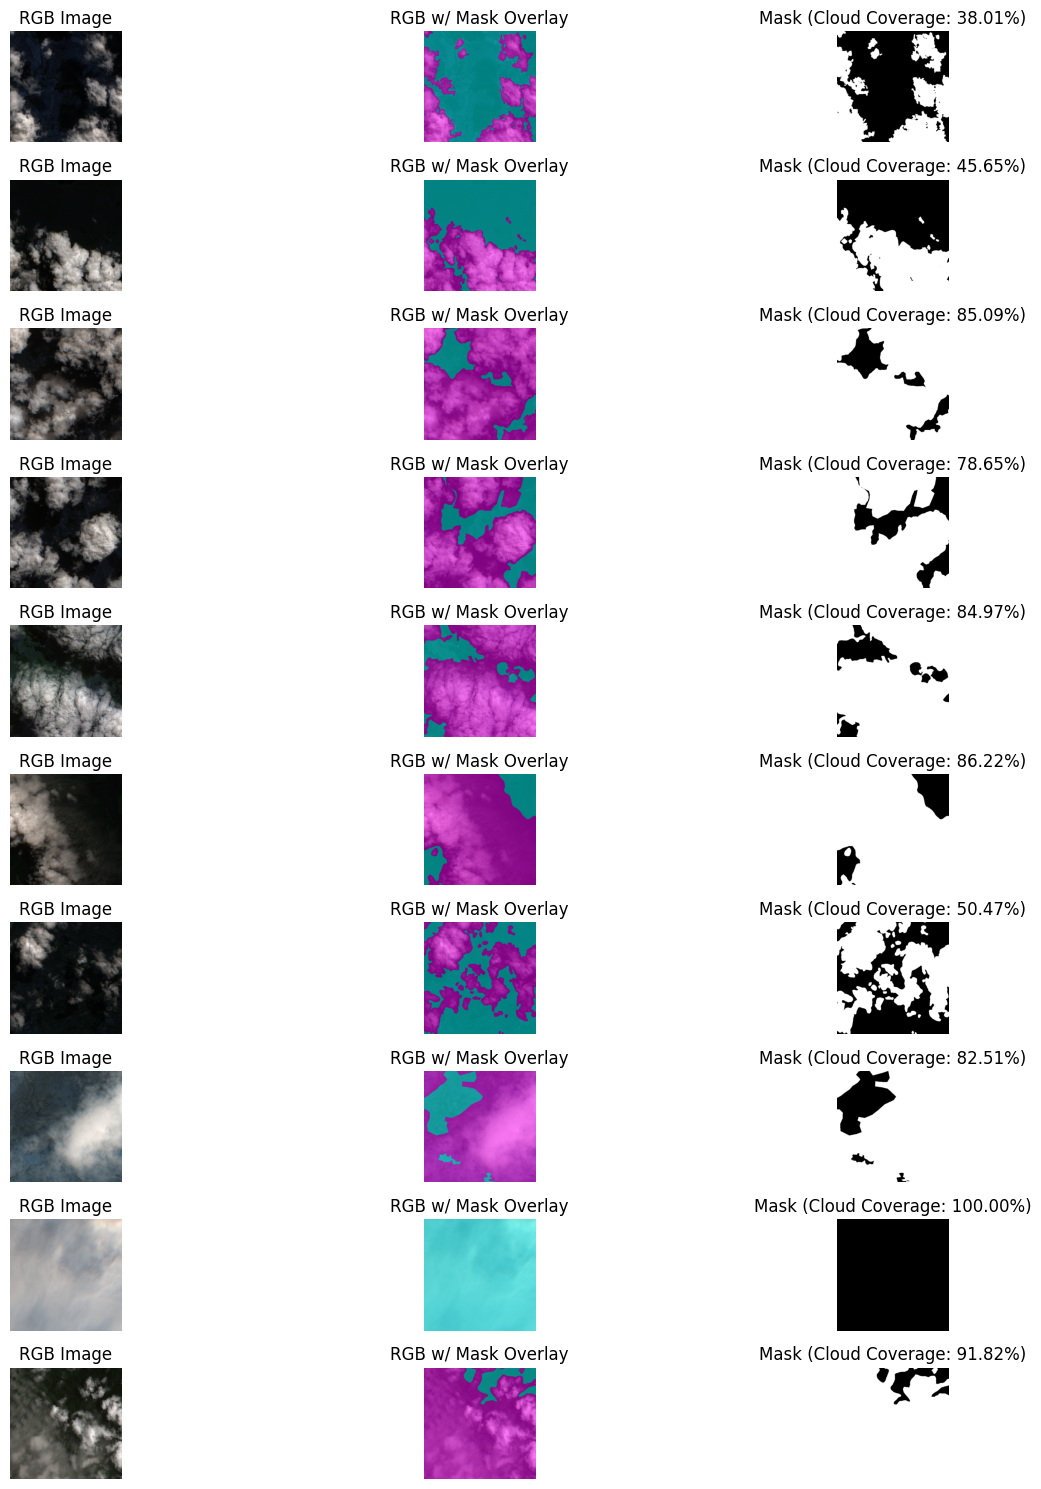

In [14]:
# NOTE: You can pass a model and thresholds to filter the dataset based on Dice scores
image_paths, mask_paths = explore_dataset(model=None, lower_threshold=None, upper_threshold=None, filenames_to_ignore=filenames_to_ignore)

In [15]:
train_img_paths, val_img_paths, train_mask_paths, val_mask_paths = train_test_split(
    image_paths, mask_paths, test_size=CONFIG['val_split'], random_state=SEED
)

train_dataset = CloudDataset(train_img_paths, train_mask_paths, transform=train_transform)
val_dataset = CloudDataset(val_img_paths, val_mask_paths, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples: 8329
Validation samples: 2083


In [ ]:
def dice_coefficient(y_pred, y_true, smooth=1e-6):
    """
    Calculates the Dice coefficient between predicted logits and ground truth masks.

    Args:
        y_pred (torch.Tensor): Predicted logits.
        y_true (torch.Tensor): Ground truth masks.
        smooth (float, optional): Smoothing constant to avoid division by zero. Defaults to 1e-6.

    Returns:
        float: Dice coefficient score.
    """
    y_pred = torch.sigmoid(y_pred)
    y_pred = (y_pred > 0.5).float()
    
    intersection = torch.sum(y_true * y_pred)
    return (2. * intersection + smooth) / (torch.sum(y_true) + torch.sum(y_pred) + smooth)

def dice_loss(pred, target, smooth=1e-6):
    """
    Computes the Dice loss between the predicted logits and target masks.

    Args:
        pred (torch.Tensor): Predicted logits.
        target (torch.Tensor): Target (ground truth) masks.
        smooth (float, optional): Smoothing constant to avoid division by zero. Defaults to 1e-6.

    Returns:
        torch.Tensor: Dice loss value.
    """
    pred = torch.sigmoid(pred)
    pred_flat = pred.contiguous().view(-1)
    target_flat = target.contiguous().view(-1)
    
    intersection = (pred_flat * target_flat).sum()
    denominator = pred_flat.sum() + target_flat.sum()
    return 1 - (2. * intersection + smooth) / (denominator + smooth)

def jaccard_loss(pred, target, smooth=1e-6):
    """
    Computes the Jaccard loss (1 - IoU) between predicted logits and target masks.

    Args:
        pred (torch.Tensor): Predicted logits.
        target (torch.Tensor): Target (ground truth) masks.
        smooth (float, optional): Smoothing constant to avoid division by zero. Defaults to 1e-6.

    Returns:
        torch.Tensor: Jaccard loss value.
    """
    pred = torch.sigmoid(pred)
    pred_flat = pred.contiguous().view(-1)
    target_flat = target.contiguous().view(-1)
    
    intersection = (pred_flat * target_flat).sum()
    total = (pred_flat + target_flat).sum()
    union = total - intersection
    
    return 1 - (intersection + smooth) / (union + smooth)

def combined_loss(pred, target, metrics=None, 
                 bce_weight=0.5, dice_weight=0.3, jaccard_weight=0.2):
    """
    Calculates a weighted combination of binary cross-entropy, dice loss, and Jaccard loss.

    Args:
        pred (torch.Tensor): Predicted logits.
        target (torch.Tensor): Target (ground truth) masks.
        metrics (dict, optional): Dictionary to accumulate loss metrics per batch. Defaults to None.
        bce_weight (float, optional): Weight for BCE loss. Defaults to 0.5.
        dice_weight (float, optional): Weight for Dice loss. Defaults to 0.3.
        jaccard_weight (float, optional): Weight for Jaccard loss. Defaults to 0.2.

    Returns:
        torch.Tensor: Combined loss value.
    """
    bce = F.binary_cross_entropy_with_logits(pred, target)
    dice = dice_loss(pred, target)
    jaccard = jaccard_loss(pred, target)
    
    loss = (bce_weight * bce + 
           dice_weight * dice + 
           jaccard_weight * jaccard)
    
    if metrics is not None:
        metrics['bce'] += bce.item() * target.size(0)
        metrics['dice'] += dice.item() * target.size(0)
        metrics['jaccard'] += jaccard.item() * target.size(0)
        metrics['loss'] += loss.item() * target.size(0)
    
    return loss

In [ ]:
def get_model(encoder='resnet34'):
    """
    Instantiates a DeepLabV3 model with the specified encoder and 4 input channels.

    Args:
        encoder (str, optional): Encoder backbone to use for DeepLabV3. Defaults to 'resnet34'.

    Returns:
        torch.nn.Module: DeepLabV3 model instance.
    """
    model = smp.DeepLabV3(
        encoder_name=encoder,
        encoder_weights="imagenet",
        in_channels=4,
        classes=1,
        activation="sigmoid",
    )
    
    return model

In [ ]:
def train_epoch(model, loader, optimizer, device):
    """
    Runs one epoch of training over a data loader, returning average loss and Dice coefficient.

    Args:
        model (torch.nn.Module): Model to train.
        loader (DataLoader): DataLoader for the training dataset.
        optimizer (torch.optim.Optimizer): Optimizer for training.
        device (torch.device): Device to run training on.

    Returns:
        tuple: (average_loss, average_dice)
            average_loss (float): Mean loss over the epoch.
            average_dice (float): Mean Dice coefficient over the epoch.
    """
    model.train()
    epoch_loss = 0
    epoch_dice = 0
    scaler = GradScaler()
    
    with tqdm(total=len(loader), desc="Training") as pbar:
        for batch_idx, (data, target) in enumerate(loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()

            with autocast():
                output = model(data)
                loss = combined_loss(output, target)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            epoch_loss += loss.item()
            
            with torch.no_grad():
                dice = dice_coefficient(output, target)
                epoch_dice += dice.item()
            
            pbar.update(1)
            pbar.set_postfix({"loss": epoch_loss/(batch_idx+1), "dice": epoch_dice/(batch_idx+1)})
    
    return epoch_loss / len(loader), epoch_dice / len(loader)

In [ ]:
def validate(model, loader, device):
    """
    Runs one epoch of validation over a data loader, returning average validation loss and Dice coefficient.

    Args:
        model (torch.nn.Module): Model to evaluate.
        loader (DataLoader): DataLoader for the validation dataset.
        device (torch.device): Device to run validation on.

    Returns:
        tuple: (average_val_loss, average_val_dice)
            average_val_loss (float): Mean validation loss.
            average_val_dice (float): Mean validation Dice coefficient.
    """
    model.eval()
    val_loss = 0
    val_dice = 0
    
    with torch.no_grad():
        with tqdm(total=len(loader), desc="Validation") as pbar:
            for batch_idx, (data, target) in enumerate(loader):
                data, target = data.to(device), target.to(device)
                
                output = model(data)
                
                loss = combined_loss(output, target)
                val_loss += loss.item()
                
                dice = dice_coefficient(output, target)
                val_dice += dice.item()
                
                pbar.update(1)
                pbar.set_postfix({"val_loss": val_loss/(batch_idx+1), "val_dice": val_dice/(batch_idx+1)})
    
    return val_loss / len(loader), val_dice / len(loader)

In [ ]:
def train_model(encoder='resnet34'):
    """
    Trains a DeepLabV3 model with the specified encoder on the training dataset.
    Tracks training and validation loss/Dice, saves the best model, and displays performance plots.

    Args:
        encoder (str, optional): Encoder backbone for DeepLabV3. Defaults to 'resnet34'.

    Returns:
        torch.nn.Module: Best-performing model loaded with the best weights.
    """
    model = get_model(encoder)
    model = model.to(CONFIG['device'])
    
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3, verbose=True
    )
    
    writer = SummaryWriter(os.path.join(OUTPUT_DIR, 'logs'))
    
    best_dice = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': []}
    
    print("Starting training...")
    
    for epoch in range(CONFIG['epochs']):
        print(f"\nEpoch {epoch+1}/{CONFIG['epochs']}")
        
        train_loss, train_dice = train_epoch(model, train_loader, optimizer, CONFIG['device'])
        history['train_loss'].append(train_loss)
        history['train_dice'].append(train_dice)
        
        val_loss, val_dice = validate(model, val_loader, CONFIG['device'])
        history['val_loss'].append(val_loss)
        history['val_dice'].append(val_dice)
        
        writer.add_scalar('Loss/train', train_loss, epoch)
        writer.add_scalar('Loss/val', val_loss, epoch)
        writer.add_scalar('Dice/train', train_dice, epoch)
        writer.add_scalar('Dice/val', val_dice, epoch)
        
        print(f"Train Loss: {train_loss:.4f}, Train Dice: {train_dice:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Dice: {val_dice:.4f}")
        
        scheduler.step(val_dice)
        
        if val_dice > best_dice:
            best_dice = val_dice
            print(f"Saving best model with Dice coefficient: {best_dice:.4f}")
            torch.save(model.state_dict(), MODEL_PATH.replace('.pkl', '.pt'))
    
    with open(MODEL_PATH, 'wb') as f:
        pickle.dump(model, f)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_dice'], label='Train Dice')
    plt.plot(history['val_dice'], label='Validation Dice')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Coefficient')
    plt.title('Training and Validation Dice Coefficient')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    writer.close()
    
    model.load_state_dict(torch.load(MODEL_PATH.replace('.pkl', '.pt')))
    
    return model

In [21]:
# NOTE: Uncomment the following to train the model
# model = train_model()

In [ ]:
def visualize_predictions(model, loader, device, num_samples=5):
    """
    Visualizes predictions by displaying image, ground truth, and predicted masks from the dataset loader.

    Args:
        model (torch.nn.Module): Trained model for inference.
        loader (DataLoader): DataLoader to sample image/mask pairs from.
        device (torch.device): Device for inference.
        num_samples (int, optional): Number of samples to visualize. Defaults to 5.

    Returns:
        None
    """
    model.eval()
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    
    with torch.no_grad():
        for i, (data, target) in enumerate(loader):
            if i >= num_samples:
                break
            
            data, target = data.to(device), target.to(device)
            output = model(data)
            output = (torch.sigmoid(output) > 0.5).float()
            
            img = data[0].permute(1, 2, 0).cpu().numpy()[:, :, :3]  # Use RGB bands
            img = (img - img.min()) / (img.max() - img.min())  # Normalize for visualization
            
            true_mask = target[0, 0].cpu().numpy()
            pred_mask = output[0, 0].cpu().numpy()
            
            axes[i, 0].imshow(img)
            axes[i, 0].set_title("Image (RGB)")
            axes[i, 0].axis("off")
            
            axes[i, 1].imshow(true_mask, cmap="gray")
            axes[i, 1].set_title("Ground Truth")
            axes[i, 1].axis("off")
            
            axes[i, 2].imshow(pred_mask, cmap="gray")
            axes[i, 2].set_title("Prediction")
            axes[i, 2].axis("off")
    
    plt.tight_layout()
    plt.show()

In [ ]:
def analyze_worst_cases(model, loader, device, num_samples=5):
    """
    Identifies and visualizes the samples with the lowest Dice scores from a dataset loader.

    Args:
        model (torch.nn.Module): Trained model for inference.
        loader (DataLoader): DataLoader to sample image/mask pairs from.
        device (torch.device): Device for inference.
        num_samples (int, optional): Number of worst-case samples to visualize. Defaults to 5.

    Returns:
        None
    """
    model.eval()
    
    results = []
    
    with torch.no_grad():
        for i, (data, target) in enumerate(loader):
            data, target = data.to(device), target.to(device)
            output = model(data)
            output = torch.sigmoid(output)
            
            for j in range(data.size(0)):
                pred = (output[j] > 0.5).float()
                truth = target[j]
                
                intersection = torch.sum(truth * pred)
                dice = (2. * intersection) / (torch.sum(truth) + torch.sum(pred) + 1e-6)
                
                results.append({
                    'dice': dice.item(),
                    'data': data[j].cpu(),
                    'target': target[j].cpu(),
                    'output': output[j].cpu()
                })
    
    results.sort(key=lambda x: x['dice'])
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    
    for i in range(num_samples):
        img = results[i]['data'].permute(1, 2, 0).numpy()[:, :, :3]
        img = (img - img.min()) / (img.max() - img.min())  # Normalize for visualization
        
        true_mask = results[i]['target'][0].numpy()
        pred_mask = (results[i]['output'][0] > 0.5).float().numpy()
        
        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Image (RGB)")
        axes[i, 0].axis("off")
        
        axes[i, 1].imshow(true_mask, cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")
        
        axes[i, 2].imshow(pred_mask, cmap="gray")
        title = f"Prediction (Dice = {results[i]['dice']:.4f})"
        axes[i, 2].set_title(title)
        axes[i, 2].axis("off")
    
    plt.tight_layout()
    plt.show()

In [24]:
# NOTE: Uncomment the following to visualize predictions and analyze worst cases

# visualize_predictions(model, val_loader, CONFIG['device'])
# analyze_worst_cases(model, val_loader, CONFIG['device'])

In [ ]:
def count_parameters(model):
    """
    Counts the number of trainable parameters in a PyTorch model.

    Args:
        model (torch.nn.Module): Model to analyze.

    Returns:
        int: The number of trainable parameters in the model.
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def profile_model(model):
    """
    Profiles the given model to estimate resource usage (parameters, FLOPs) 
    and writes the summary to a log file.

    Args:
        model (torch.nn.Module): Model to profile.

    Returns:
        None
    """
    input_tensor = torch.randn(1, 4, CONFIG['img_size'], CONFIG['img_size']).to(CONFIG['device'])
    
    with profile(
        activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
        profile_memory=True,
        record_shapes=True
    ) as prof:
        with record_function("model_inference"):
            _ = model(input_tensor)
    
    flops_estimate = prof.key_averages().total_average().flops    
    total_params = count_parameters(model)
    
    with open(LOGS_PATH, 'w') as f:
        f.write(f"Model: UNet with ResNet34 backbone\n")
        f.write(f"Total parameters: {total_params:,}\n")
        if flops_estimate:
            f.write(f"Estimated FLOPs: {flops_estimate:,}\n")
        else:
            f.write(f"Operations: Profile data available in tensorboard logs\n")
        f.write(f"Input shape: (4, {CONFIG['img_size']}, {CONFIG['img_size']})\n")
        f.write(f"Output shape: (1, {CONFIG['img_size']}, {CONFIG['img_size']})\n")
    
    print(f"Model statistics:")
    print(f"- Total parameters: {total_params:,}")
    if flops_estimate:
        print(f"- Estimated FLOPs: {flops_estimate:,}")
    print(f"- Profile data written to {LOGS_PATH}")

In [26]:
# NOTE: Uncomment the following to profile the model
# profile_model(model)

In [ ]:
def rle_encode(mask):
    """
    Encodes a binary mask using Run-Length Encoding (RLE).
    
    Args:
        mask (np.ndarray): 2D binary mask (0s and 1s).

    Returns:
        str: RLE-encoded string, or a single space " " if mask is all zeros.
    """
    if np.sum(mask) == 0:
        return " "
    
    pixels = mask.flatten(order='F')
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    runs[::2] -= 1

    return " ".join(map(str, runs))

def rle_decode(mask_rle: str, shape=(256, 256)) -> np.ndarray:
    """
    Decodes an RLE-encoded string into a binary mask with validation checks.

    Args:
        mask_rle (str): RLE string to decode.
        shape (tuple, optional): Shape (height, width) of the output mask. Defaults to (256, 256).

    Returns:
        np.ndarray: Decoded 2D binary mask.
    """
    if not isinstance(mask_rle, str) or not mask_rle.strip() or mask_rle.lower() == 'nan':
        return np.zeros(shape, dtype=np.uint8)
    
    try:
        s = list(map(int, mask_rle.split()))
    except:
        raise Exception("RLE segmentation must be a string and containing only integers")
    
    if len(s) % 2 != 0:
        raise Exception("RLE segmentation must have even-length (start, length) pairs")
    
    if any(x < 0 for x in s):
        raise Exception("RLE segmentation must not contain negative values")
    
    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    starts, lengths = s[0::2], s[1::2]
    
    for start, length in zip(starts, lengths):
        if start >= mask.size or start + length > mask.size:
            raise Exception("RLE indices exceed image size")
        mask[start:start + length] = 1
    
    return mask.reshape(shape, order='F')

In [ ]:
def run_inference_to_csv( tiff_dir, model, csv_path, img_size, 
                         rle_size, device, threshold, show, max_show,
                        ) -> None:
    """
    Runs model inference on a directory of TIFF images, saves RLE-encoded masks to CSV,
    and optionally visualizes a subset of predictions.

    Args:
        tiff_dir (str or Path): Directory containing TIFF image files for inference.
        model (torch.nn.Module): Trained model for segmentation.
        csv_path (str or Path): Output path for the CSV file.
        img_size (int): Size to which images will be resized for inference.
        rle_size (int): Size for resizing predictions before RLE encoding.
        device (torch.device): Device for model inference.
        threshold (float): Probability threshold for binarizing model outputs.
        show (bool): Whether to display visualization of predictions.
        max_show (int): Maximum number of samples to visualize.

    Returns:
        None
    """
    tiff_paths: List[Path] = sorted(Path(tiff_dir).glob("*.tif*"))
    assert tiff_paths, f"No TIFF images found in '{tiff_dir}'."

    rows, visuals = [], []

    for p in tqdm(tiff_paths, desc="Inference"):
        with rasterio.open(p) as src:
            img4 = np.stack([src.read(i + 1) for i in range(4)], axis=2).astype(np.float32)

        for c in range(4):
            m = img4[..., c].max()
            if m > 0:
                img4[..., c] /= m

        img_r = cv2.resize(img4, (img_size, img_size), cv2.INTER_LINEAR)
        tensor = torch.from_numpy(img_r.transpose(2, 0, 1)).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = model(tensor)
            prob   = torch.sigmoid(logits)[0, 0].cpu().numpy()

        mask_pred = (prob > threshold).astype(np.uint8)

        mask_rle = resize(mask_pred, (rle_size, rle_size), order=0, preserve_range=True, anti_aliasing=False).astype(np.uint8)
        rows.append(
            {
                "id": p.stem,
                "segmentation": rle_encode(mask_rle),
            }
        )

        if show and len(visuals) < max_show:
            rgb_disp = img_r[..., :3]
            rgb_disp = (rgb_disp - rgb_disp.min()) / (rgb_disp.ptp() + 1e-6)
            visuals.append((rgb_disp, mask_pred))

    df = pd.DataFrame(rows)
    df["id"] = df["id"].astype(str)
    df.to_csv(csv_path, index=False)
    print(f"\nSaved {len(rows)} predictions → {csv_path}")

    if show and visuals:
        n_vis       = len(visuals)
        dpi         = plt.rcParams.get("figure.dpi", 100)
        row_height  = 3.0
        max_inches  = 65500 / dpi
        rows_per_fig_max = int(max_inches // row_height)
    
        for chunk_idx in range(0, n_vis, rows_per_fig_max):
            chunk = visuals[chunk_idx : chunk_idx + rows_per_fig_max]
            rows  = len(chunk)
            fig, axes = plt.subplots(rows, 3,
                                     figsize=(12, row_height * rows),
                                     squeeze=False)
    
            for r, (rgb, msk) in enumerate(chunk):
                axes[r, 0].imshow(rgb)
                axes[r, 0].set_title("Resized RGB")
                axes[r, 0].axis("off")
    
                axes[r, 1].imshow(rgb)
                axes[r, 1].imshow(msk, alpha=0.5, cmap="cool")
                axes[r, 1].set_title("Mask overlay")
                axes[r, 1].axis("off")
    
                axes[r, 2].imshow(msk, cmap="gray")
                axes[r, 2].set_title("Binary mask")
                axes[r, 2].axis("off")
    
            fig.tight_layout()
            plt.show()

Inference: 100%|██████████| 316/316 [00:23<00:00, 13.69it/s]



Saved 316 predictions → team_18.csv


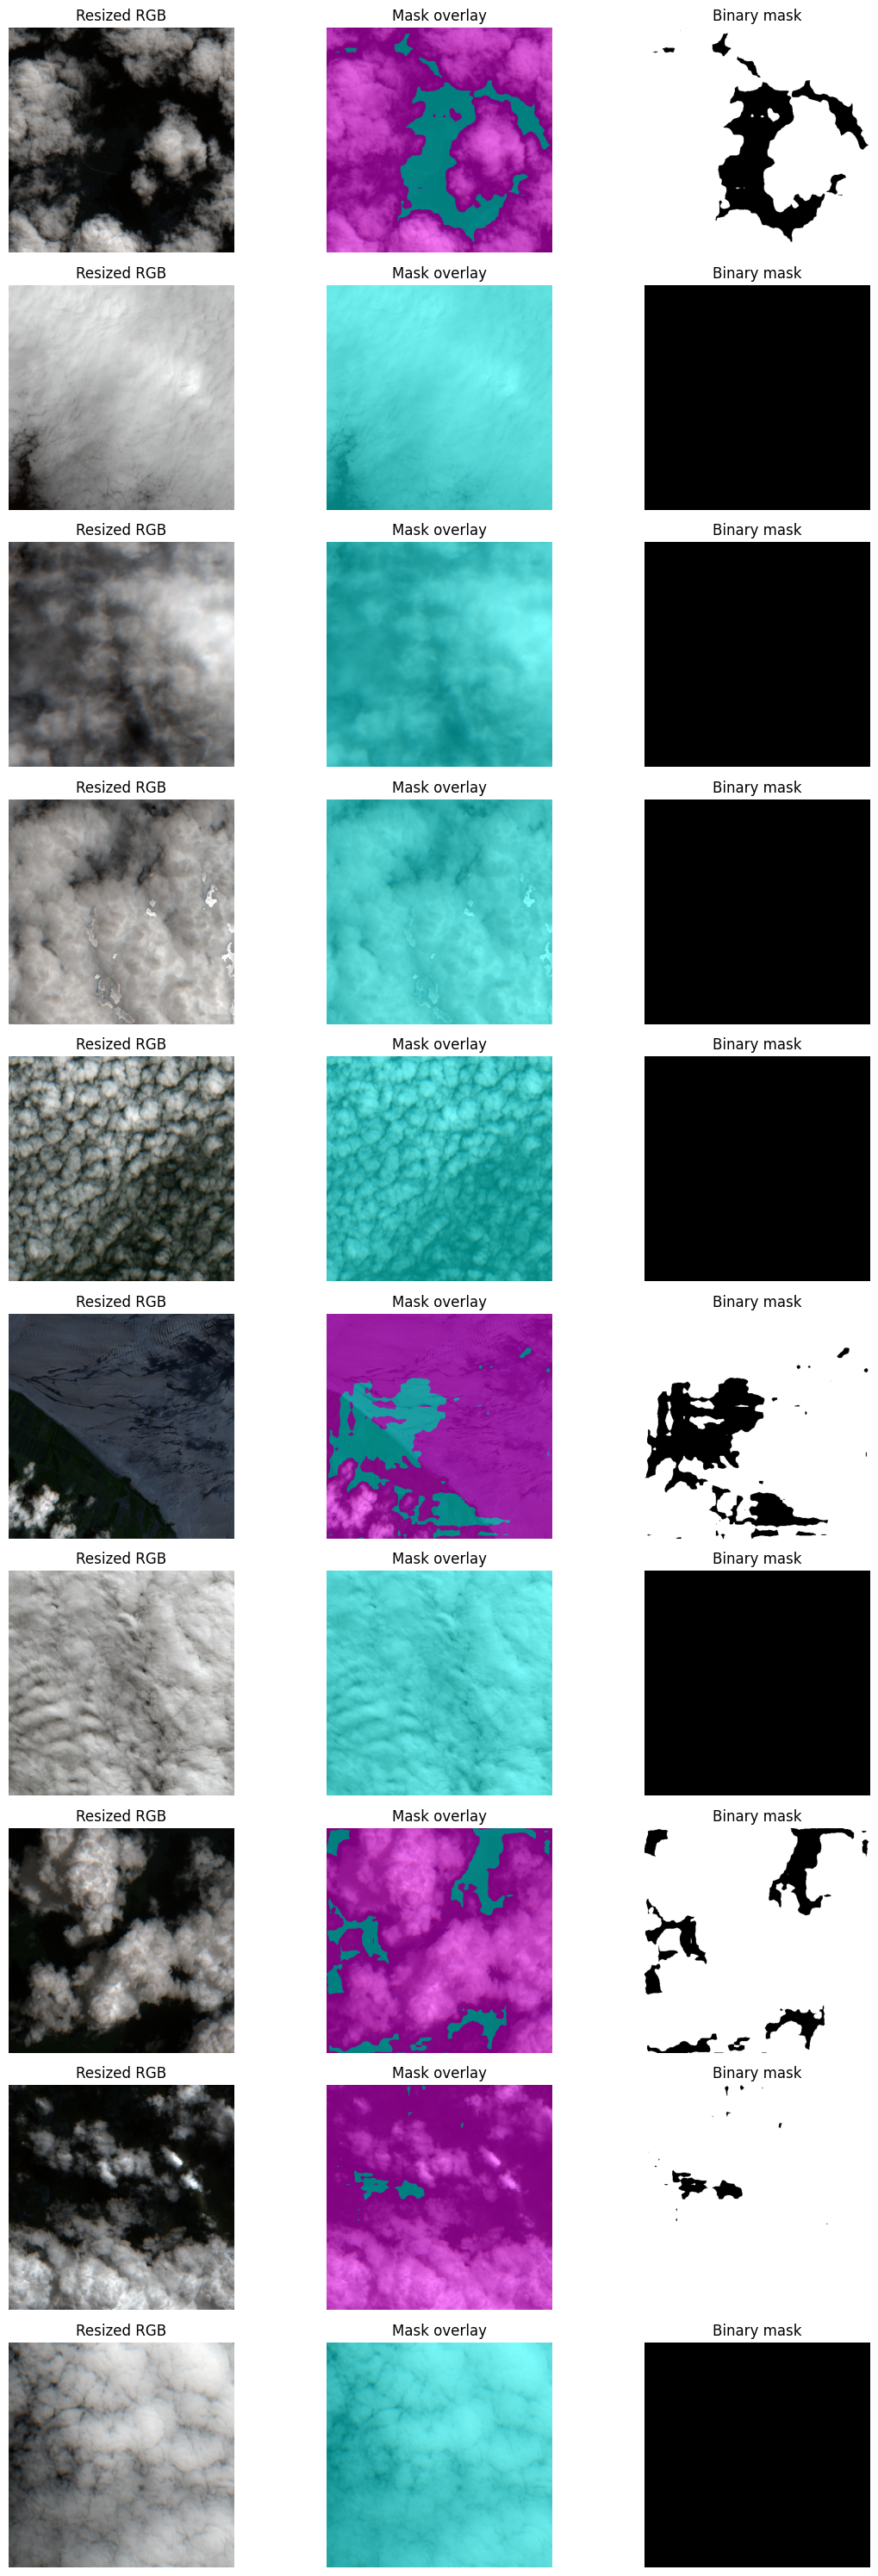

In [29]:
TEST_SET = "/kaggle/input/cloud-masking-test-set-satellite-cmp25-course/test/test/data"
DEEP_LAB_MODEL_PATH = "/kaggle/input/cloud-mask-deep-lab/pytorch/default/1/cloud_mask_deeplab.pkl"

deep_lab_model = load_model(DEEP_LAB_MODEL_PATH)

run_inference_to_csv(
    tiff_dir=Path(TEST_SET),
    model=deep_lab_model,
    csv_path="team_18.csv",
    img_size=512,
    rle_size=256,
    device=CONFIG['device'],
    threshold=0.5,
    show=True,
    max_show=10,
)